In [1]:
import os 
print(os.listdir())

['.ipynb_checkpoints', 'Coding.ipynb', 'student_result.csv']


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("student_result.csv")
print(df.head())

   Unnamed  Gender ParentMaritalStatus IsFristChild TransportMean  \
0        1    Male              Single          Yes           Bus   
1        2    Male              Single           No          Bike   
2        3  Female            Divorced          Yes           Bus   
3        4    Male             Married           No           Bus   
4        5    Male              Single          Yes           Car   

        TestPrep  WritingScore  ReadingScore  MathScore     LunchType  \
0      Completed            39            41         35  Free/Reduced   
1  Not Completed            81            72         64  Free/Reduced   
2  Not Completed            45            49         59      Standard   
3  Not Completed            90            86         93  Free/Reduced   
4  Not Completed            88            89         78  Free/Reduced   

  PracticeSport  NrSibling ParentEducation EthnicGroup  
0     Regularly          0     High School     Group B  
1     Regularly          1      

In [25]:
print(df.describe())

          Unnamed  WritingScore  ReadingScore   MathScore   NrSibling
count  500.000000    500.000000    500.000000  500.000000  500.000000
mean   250.500000     71.376000     70.796000   70.874000    2.428000
std    144.481833     17.433142     17.030398   18.144547    1.718931
min      1.000000     35.000000     40.000000   30.000000    0.000000
25%    125.750000     58.750000     57.000000   57.000000    1.000000
50%    250.500000     72.000000     72.000000   72.000000    2.000000
75%    375.250000     86.000000     86.000000   86.000000    4.000000
max    500.000000    100.000000    100.000000  100.000000    5.000000


In [26]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Unnamed              500 non-null    int64
 1   Gender               500 non-null    str  
 2   ParentMaritalStatus  500 non-null    str  
 3   IsFristChild         500 non-null    str  
 4   TransportMean        500 non-null    str  
 5   TestPrep             500 non-null    str  
 6   WritingScore         500 non-null    int64
 7   ReadingScore         500 non-null    int64
 8   MathScore            500 non-null    int64
 9   LunchType            500 non-null    str  
 10  PracticeSport        500 non-null    str  
 11  NrSibling            500 non-null    int64
 12  ParentEducation      500 non-null    str  
 13  EthnicGroup          500 non-null    str  
dtypes: int64(5), str(9)
memory usage: 54.8 KB
None


In [31]:
print(df.isnull().sum())

Gender                 0
ParentMaritalStatus    0
IsFristChild           0
TransportMean          0
TestPrep               0
WritingScore           0
ReadingScore           0
MathScore              0
LunchType              0
PracticeSport          0
NrSibling              0
ParentEducation        0
EthnicGroup            0
TotalScore             0
AverageScore           0
dtype: int64


#Drop Unnamed Column


In [29]:
df = df.drop("Unnamed:0", axis=1, errors='ignore')
print(df.head())


   Gender ParentMaritalStatus IsFristChild TransportMean       TestPrep  \
0    Male              Single          Yes           Bus      Completed   
1    Male              Single           No          Bike  Not Completed   
2  Female            Divorced          Yes           Bus  Not Completed   
3    Male             Married           No           Bus  Not Completed   
4    Male              Single          Yes           Car  Not Completed   

   WritingScore  ReadingScore  MathScore     LunchType PracticeSport  \
0            39            41         35  Free/Reduced     Regularly   
1            81            72         64  Free/Reduced     Regularly   
2            45            49         59      Standard     Sometimes   
3            90            86         93  Free/Reduced         Never   
4            88            89         78  Free/Reduced         Never   

   NrSibling ParentEducation EthnicGroup  
0          0     High School     Group B  
1          1             PhD  

#Total and Average Marks of Student

In [30]:
df['TotalScore']=df['WritingScore'] + df['ReadingScore'] + df['MathScore']
df['AverageScore']=df['TotalScore']/3
print(df.head())

   Gender ParentMaritalStatus IsFristChild TransportMean       TestPrep  \
0    Male              Single          Yes           Bus      Completed   
1    Male              Single           No          Bike  Not Completed   
2  Female            Divorced          Yes           Bus  Not Completed   
3    Male             Married           No           Bus  Not Completed   
4    Male              Single          Yes           Car  Not Completed   

   WritingScore  ReadingScore  MathScore     LunchType PracticeSport  \
0            39            41         35  Free/Reduced     Regularly   
1            81            72         64  Free/Reduced     Regularly   
2            45            49         59      Standard     Sometimes   
3            90            86         93  Free/Reduced         Never   
4            88            89         78  Free/Reduced         Never   

   NrSibling ParentEducation EthnicGroup  TotalScore  AverageScore  
0          0     High School     Group B       

#Gap of Score

In [32]:
df['ScoreGap']=df['ReadingScore']-df['WritingScore']
print(df.head())

   Gender ParentMaritalStatus IsFristChild TransportMean       TestPrep  \
0    Male              Single          Yes           Bus      Completed   
1    Male              Single           No          Bike  Not Completed   
2  Female            Divorced          Yes           Bus  Not Completed   
3    Male             Married           No           Bus  Not Completed   
4    Male              Single          Yes           Car  Not Completed   

   WritingScore  ReadingScore  MathScore     LunchType PracticeSport  \
0            39            41         35  Free/Reduced     Regularly   
1            81            72         64  Free/Reduced     Regularly   
2            45            49         59      Standard     Sometimes   
3            90            86         93  Free/Reduced         Never   
4            88            89         78  Free/Reduced         Never   

   NrSibling ParentEducation EthnicGroup  TotalScore  AverageScore  ScoreGap  
0          0     High School     Grou

#Gender Distribution

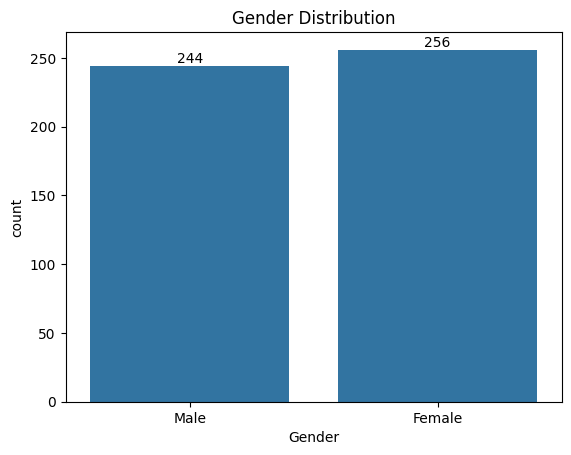

In [15]:
ax=sns.countplot(data=df, x="Gender")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show()

In [ ]:
#from above chart we have analyzed that:
#the number of female in data is greater then number of male

In [13]:
gb=df.groupby("ParentEducation").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb)

                 MathScore  ReadingScore  WritingScore
ParentEducation                                       
Bachelor         71.409091     70.897727     71.272727
High School      69.611111     70.777778     71.370370
Intermediate     70.028846     69.423077     70.519231
Master           72.309278     71.824742     72.082474
PhD              71.242718     71.145631     71.669903


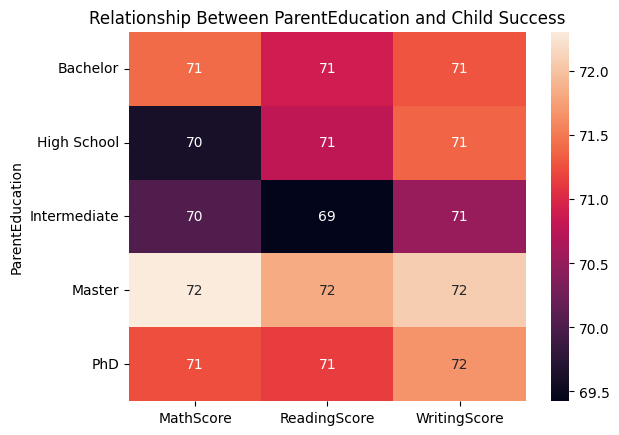

In [14]:
sns.heatmap(gb, annot=True)
plt.title("Relationship Between ParentEducation and Child Success")
plt.show()

In [ ]:
#from above chart we have concluded that the education of parent have a good impact on 

In [10]:
gb1=df.groupby("ParentMaritalStatus").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gb1.head())

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
Divorced             70.955556     70.577778     71.637037
Married              73.336449     72.953271     74.186916
Single               68.447761     68.865672     68.850746
Widowed              71.282258     71.258065     71.395161


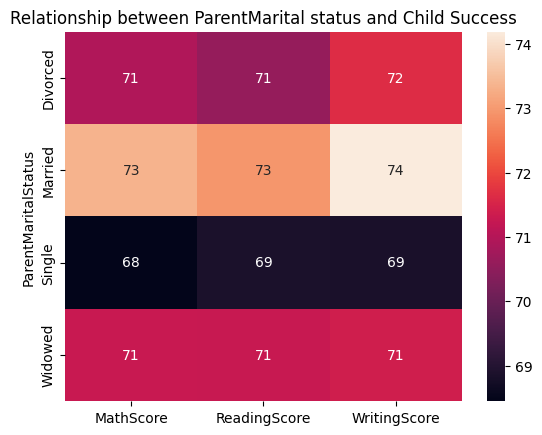

In [11]:
sns.heatmap(gb1, annot=True)
plt.title("Relationship between ParentMarital status and Child Success")
plt.show()

In [ ]:
#from above chart we concludedt that children of married people score heighst which is 73-74 so yes
#Children with single parent have lowest scores-around 68-69.
#Divorced and windowed parent are in middle ,around 71
#parentl marital status does have a small impact on clid success  

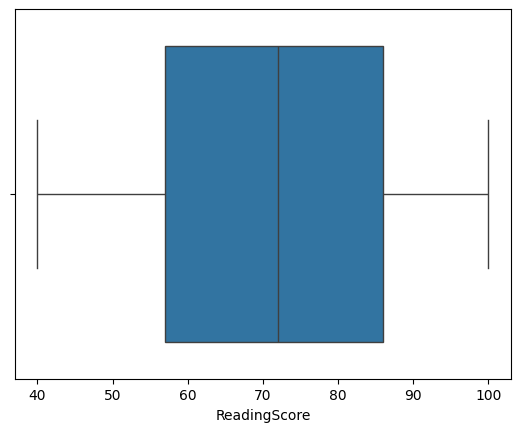

In [27]:
sns.boxplot(data = df, x = "ReadingScore")
plt.show()

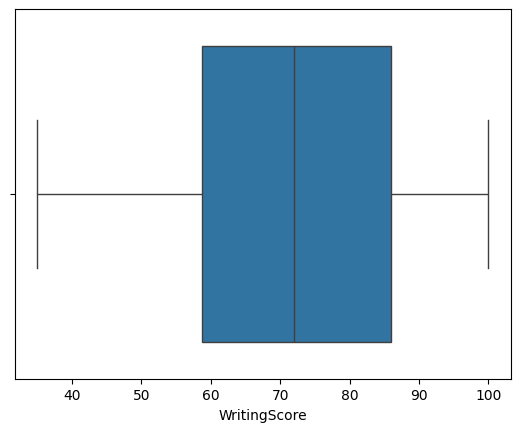

In [28]:
sns.boxplot(data=df, x = "WritingScore")
plt.show()

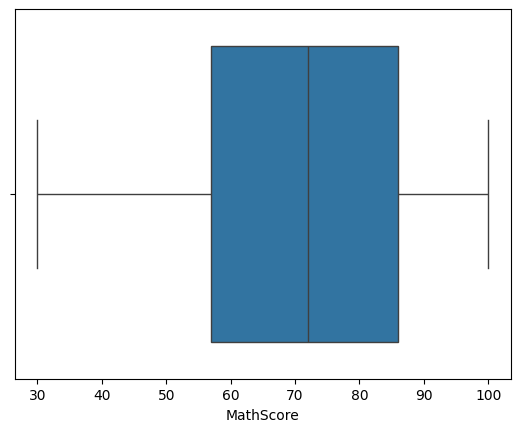

In [29]:
sns.boxplot(data=df, x="MathScore")
plt.show()

In [36]:
print(df["EthnicGroup"].unique())

<StringArray>
['Group B', 'Group C', 'Group A', 'Group D']
Length: 4, dtype: str


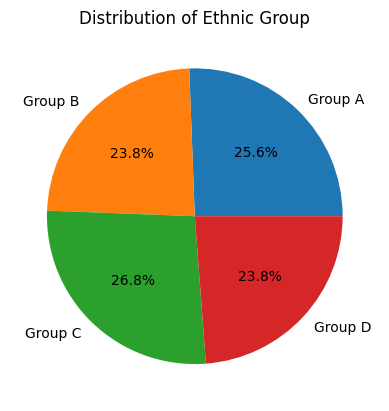

In [51]:
groupA = df.loc[(df["EthnicGroup"]=="Group A")].shape[0]
groupB=df.loc[(df["EthnicGroup"]=="Group B")].shape[0]
groupC=df.loc[(df["EthnicGroup"]=="Group C")].shape[0]
groupD=df.loc[(df["EthnicGroup"]=="Group D")].shape[0]
mlist= [groupA,groupB,groupC,groupD]
labels=["Group A", "Group B", "Group C", "Group D"]
plt.pie(mlist, labels=labels, autopct='%1.1f%%')
plt.title("Distribution of Ethnic Group")
plt.show()

[Text(0, 0, '119'), Text(0, 0, '134'), Text(0, 0, '128'), Text(0, 0, '119')]

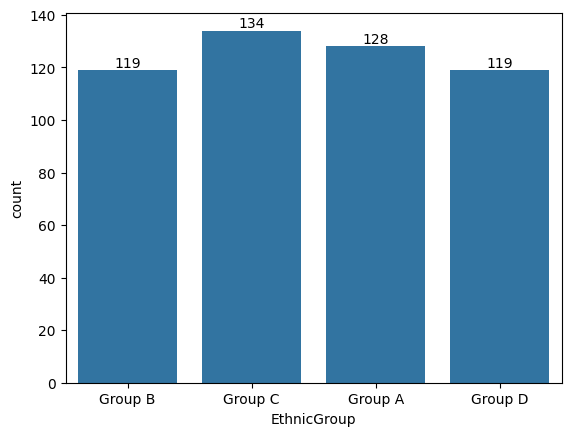

In [52]:
ax=sns.countplot(data=df, x="EthnicGroup")
ax.bar_label(ax.containers[0])